<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">

# Procesamiento de lenguaje natural
## Custom embeddings con Gensim

## **Consigna del Desafío 2**
**Cada experimento realizado debe estar acompañado de una explicación o interpretación de lo observado.**

- Crear mis propios vectores con Gensim basado en lo visto en clase con un corpus propio.
- Elegir términos de interés y buscar términos más similares y menos similares.
- Realizar una reducción de dimensionalidad a los embeddings, llevándolos a 2 dimensiones. Graficar los embeddings proyectados y seleccionar una cantidad de términos (variable `MAX_WORDS`) de forma tal que la visualización sea adecuada.
- Inspeccionar el gráfico y buscar pequeños grupos de palabras que puedan formarse. Interpretarlos e intentar obtener conclusiones.

## **Resolución del Desafío 2**

### Corpus elegido: Radiohead

Voy a utilizar el archivo `radiohead.txt` del `songs_dataset` (letras de canciones de Radiohead) como corpus para entrenar mis propios embeddings con Word2Vec. Elegí esta banda porque su discografía cubre muchos discos con temáticas y vocabulario bastante variado (alienación, tecnología, paranoia, naturaleza, relaciones), lo que debería dar lugar a agrupamientos semánticos interesantes de interpretar.

Lo primero que hago es importar las bibliotecas que voy a necesitar.

In [1]:
import os
import platform
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from gensim.models import Word2Vec
from gensim.models.callbacks import CallbackAny2Vec
from sklearn.manifold import TSNE

# Fijo una semilla para que los resultados (entrenamiento del modelo y t-SNE) sean reproducibles
SEED = 19
np.random.seed(SEED)

### 1 - Datos y preprocesamiento

In [2]:
# Descargo la carpeta del dataset si todavía no la tengo localmente
if os.access('./songs_dataset', os.F_OK) is False:
    if os.access('songs_dataset.zip', os.F_OK) is False:
        if platform.system() == 'Windows':
            !curl https://raw.githubusercontent.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/main/datasets/songs_dataset.zip -o songs_dataset.zip
        else:
            !wget -O songs_dataset.zip https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/raw/main/datasets/songs_dataset.zip
    !unzip -q -o songs_dataset.zip
else:
    print("El dataset ya se encuentra descargado")

El dataset ya se encuentra descargado


In [3]:
# Armo el dataset utilizando el salto de línea para separar las oraciones/docs
# (mantengo el separador '/n' -que no matchea nada como regex- para que pandas
# use cada línea del archivo como un único documento, igual que en el ejemplo de la cátedra)
df = pd.read_csv('songs_dataset/radiohead.txt', sep='/n', header=None, engine='python')
print("Cantidad de documentos (líneas de letras):", df.shape[0])
df.head()

Cantidad de documentos (líneas de letras): 2343


,0
0,"Come on, come on"
1,You think you drive me crazy
2,"Come on, come on"
3,You and whose army?
4,You and your cronies


**Tokenización**

En el notebook de ejemplo de la cátedra se utiliza `text_to_word_sequence` de `tensorflow.keras`. Para no agregar una dependencia tan pesada como TensorFlow solo para tokenizar, implemento una función equivalente: pasa el texto a minúsculas y elimina los mismos signos de puntuación que filtra por default `text_to_word_sequence` (`!"#$%&()*+,-./:;<=>?@[\]^_`{|}~\t\n`), y después separa por espacios.

In [4]:
FILTERS = '!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n'
TRANSLATE_MAP = str.maketrans(FILTERS, ' ' * len(FILTERS))

def tokenize(text):
    """Equivalente a text_to_word_sequence de Keras: minúsculas + elimina puntuación + split por espacios."""
    text = str(text).lower().translate(TRANSLATE_MAP)
    return [token for token in text.split(' ') if token]

sentence_tokens = [tokenize(row) for row in df[0]]

# Demos un vistazo
sentence_tokens[:5]

[['come', 'on', 'come', 'on'],
 ['you', 'think', 'you', 'drive', 'me', 'crazy'],
 ['come', 'on', 'come', 'on'],
 ['you', 'and', 'whose', 'army'],
 ['you', 'and', 'your', 'cronies']]

In [5]:
print("Cantidad de oraciones/documentos tokenizados:", len(sentence_tokens))
print("Cantidad total de tokens en el corpus:", sum(len(s) for s in sentence_tokens))

Cantidad de oraciones/documentos tokenizados: 2343
Cantidad total de tokens en el corpus: 11803


**Observación:** las letras de Radiohead tienen bastante repetición de versos (coros, estribillos), por lo que la cantidad de tokens totales es baja comparada con un corpus de texto libre, pero eso también ayuda a que las palabras temáticas que sí se repiten (`black`, `world`, `eyes`, etc.) tengan suficientes apariciones en contexto como para aprender un embedding razonable con un `min_count` bajo.

### 2 - Crear los vectores (Word2Vec)

In [6]:
# Durante el entrenamiento gensim por defecto no informa el "loss" en cada época,
# sobrecargo el callback para poder tener esta información (igual que en el ejemplo de la cátedra)
class callback(CallbackAny2Vec):
    """Callback para imprimir el loss después de cada época"""
    def __init__(self):
        self.epoch = 0

    def on_epoch_end(self, model):
        loss = model.get_latest_training_loss()
        if self.epoch == 0:
            print('Loss after epoch {}: {}'.format(self.epoch, loss))
        else:
            print('Loss after epoch {}: {}'.format(self.epoch, loss - self.loss_previous_step))
        self.epoch += 1
        self.loss_previous_step = loss

Elijo los hiperparámetros del modelo pensando en que el corpus es chico (~2300 líneas, poco más de 500 palabras distintas con una frecuencia mínima razonable):

- `min_count=3`: como el corpus es chico, un `min_count` muy alto (como el 5 del ejemplo de la cátedra) deja un vocabulario demasiado reducido. Con 3 me quedo con un vocabulario algo más rico sin incluir palabras que aparecen una sola vez (que no alcanzan a tener un buen embedding).
- `window=3`: una ventana de contexto un poco más amplia que el ejemplo (2), para compensar que las líneas del corpus son cortas y así capturar más co-ocurrencias por cada palabra.
- `vector_size=150`: con un vocabulario de unos cientos de palabras, 300 dimensiones (el valor del ejemplo) es demasiado para la cantidad de datos disponibles y corre riesgo de sobreajustar/quedar con vectores poco informativos. Uso 150.
- `sg=1` (Skip-gram): igual que el ejemplo, porque con corpus chicos suele funcionar mejor que CBOW para palabras poco frecuentes.
- `negative=20`: cantidad de negative samples, igual que el ejemplo.

In [7]:
# Creo el modelo generador de vectores (Skip-gram)
w2v_model = Word2Vec(
    min_count=3,        # frecuencia mínima de palabra para incluirla en el vocabulario
    window=3,            # cant. de palabras antes y después de la predicha
    vector_size=150,     # dimensionalidad de los vectores
    negative=20,          # cantidad de negative samples
    workers=1,
    sg=1,                 # modelo 0:CBOW  1:skipgram
    seed=SEED,
)

# Obtengo el vocabulario con los tokens
w2v_model.build_vocab(sentence_tokens)

print("Cantidad de docs en el corpus:", w2v_model.corpus_count)
print("Cantidad de words distintas en el corpus:", len(w2v_model.wv.index_to_key))

Cantidad de docs en el corpus: 2343
Cantidad de words distintas en el corpus: 616


### 3 - Entrenar embeddings

In [8]:
# Entreno el modelo generador de vectores, usando el callback para monitorear el loss
w2v_model.train(
    sentence_tokens,
    total_examples=w2v_model.corpus_count,
    epochs=30,
    compute_loss=True,
    callbacks=[callback()],
)

Loss after epoch 0: 122889.9765625
Loss after epoch 1: 58880.6953125
Loss after epoch 2: 55886.09375
Loss after epoch 3: 54652.546875
Loss after epoch 4: 54844.125
Loss after epoch 5: 54158.28125
Loss after epoch 6: 52936.59375
Loss after epoch 7: 52392.8125
Loss after epoch 8: 52041.25
Loss after epoch 9: 51455.25
Loss after epoch 10: 50038.5
Loss after epoch 11: 48167.6875
Loss after epoch 12: 46523.5625
Loss after epoch 13: 46438.3125
Loss after epoch 14: 45297.375
Loss after epoch 15: 44468.0
Loss after epoch 16: 44165.125
Loss after epoch 17: 42180.625
Loss after epoch 18: 41807.6875
Loss after epoch 19: 40455.75
Loss after epoch 20: 37126.25
Loss after epoch 21: 36579.875
Loss after epoch 22: 37501.375
Loss after epoch 23: 36397.0
Loss after epoch 24: 35915.75
Loss after epoch 25: 35758.875
Loss after epoch 26: 36327.75
Loss after epoch 27: 36382.125
Loss after epoch 28: 35702.0
Loss after epoch 29: 35682.0


(204319, 354090)

**Conclusión del entrenamiento**

El loss cae fuerte en la primera época (de un valor inicial alto a un valor mucho menor) y después sigue bajando de forma más gradual y sostenida a lo largo de las 30 épocas, sin señales de inestabilidad (no hay saltos hacia arriba grandes ni repetidos). Esto es un buen indicio de que el entrenamiento convergió razonablemente con estos hiperparámetros y que 30 épocas alcanzan para un corpus de este tamaño (no hace falta entrenar muchas más épocas, pero tampoco parece haberse quedado corto).

### 4 - Ensayar: términos de interés

Elijo algunos términos temáticos que aparecen con frecuencia en las letras de Radiohead (`black`, `world`, `eyes`, `rain`) y reviso con cuáles palabras del vocabulario el modelo los asocia más (`most_similar` positivo) y menos (`most_similar` negativo).

In [11]:
TERMS_OF_INTEREST = ["black", "world", "eyes", "rain"]

for term in TERMS_OF_INTEREST:
    print(f"\nPalabras MÁS similares a '{term}':")
    for word, score in w2v_model.wv.most_similar(positive=[term], topn=8):
        print(f"  {word:<12} {score:.4f}")


Palabras MÁS similares a 'black':
  star         0.9741
  throw        0.9474
  blame        0.9457
  pass         0.9408
  pretty       0.9320
  hearts       0.9304
  satellite    0.9277
  videotape    0.9264

Palabras MÁS similares a 'world':
  perfect      0.9245
  kid          0.9233
  crushed      0.9198
  fake         0.9186
  hole         0.9174
  burns        0.9137
  bug          0.9106
  ground       0.9098

Palabras MÁS similares a 'eyes':
  turtle's     0.9107
  giant        0.8635
  baby's       0.8353
  its          0.7752
  off          0.7727
  won't        0.7716
  bow          0.7676
  x            0.7556

Palabras MÁS similares a 'rain':
  broken       0.9568
  hearts       0.9561
  make         0.9449
  blame        0.9163
  black        0.9159
  door         0.9061
  star         0.8913
  break        0.8867


**Interpretación (similares positivos)**

- **`black`** se asocia con `star`, `throw`, `blame`, `pretty`, `hearts`, `satellite`, `videotape`: mezcla palabras que aparecen literalmente junto a "black" en varias canciones (`black star`, en referencia a la canción *Black Star*) con otras que comparten un tono emocional oscuro/melancólico (`blame`, `hearts`).
- **`world`** trae `perfect`, `kid`, `crushed`, `fake`, `hole`, `ground`: esto calza perfecto con la temática de *Fake Plastic Trees* / *Karma Police* / *No Surprises*, canciones donde "world" aparece asociado a la idea de un mundo artificial, aplastante o decepcionante (`fake`, `crushed`, `perfect` en tono irónico).
- **`rain`** trae `broken`, `hearts`, `make`, `blame`, `black`, `door`, `break`: son palabras que co-ocurren en el mismo puñado de versos con tono melancólico/de ruptura, algo esperable dado que "rain" en las letras suele aparecer en contextos tristes o de quiebre emocional.
- **`eyes`** da un resultado más raro (`turtle's`, `giant`, `baby's`) con valores de similaridad más bajos que las anteriores: es una palabra que aparece en pocos contextos muy distintos entre sí (ojos de tortuga, ojos de bebé, "giant eyes"), por lo que su vector queda menos "concentrado" semánticamente que el de palabras con un uso más consistente a lo largo del corpus.

En general, con un corpus tan chico (unas 2300 líneas, ~600 palabras de vocabulario) el modelo no logra capturar una relación semántica "de diccionario" pura, sino más bien relaciones de **co-ocurrencia local dentro de las canciones**: palabras que efectivamente aparecen juntas o en versos consecutivos. Esto es consistente con lo esperable de Word2Vec entrenado con muy pocos datos: la calidad del embedding depende directamente de cuántas veces una palabra aparece en contextos variados, y acá el corpus es órdenes de magnitud más chico que los corpus típicos de Word2Vec (Google News, Wikipedia, etc.).

In [12]:
# Palabras que MENOS se relacionan con "love" (most_similar negativo)
print("Palabras MENOS similares a 'love':")
for word, score in w2v_model.wv.most_similar(negative=["love"], topn=8):
    print(f"  {word:<12} {score:.4f}")

Palabras MENOS similares a 'love':
  uptight      -0.1314
  am           -0.1688
  first        -0.2047
  and          -0.2142
  here         -0.2258
  fade         -0.2369
  day          -0.2382
  hanging      -0.2463


**Interpretación (similar negativo)**

Los `most_similar(negative=[...])` dan, como es esperable, valores de similaridad de coseno bajos o negativos (entre -0.13 y -0.25): son las palabras cuyo vector queda más "opuesto" al de `love` en el espacio de embeddings. A diferencia de la búsqueda positiva, acá no hay una interpretación semántica tan clara ("uptight", "am", "first", "and"...), porque negative search no busca antónimos de "love" sino simplemente las palabras que menos comparten contexto con ella. Como el corpus es chico, esto termina siendo bastante ruidoso: alcanza con que una palabra casi no comparta ningún contexto con "love" para terminar en esta lista, sin que eso implique una oposición semántica real (por ejemplo, "and" o "am" no son "antónimos" de "love", simplemente no suelen aparecer cerca).

In [13]:
# El método get_vector permite obtener el vector de una palabra directamente,
# y most_similar también puede recibir un vector (no solo una palabra) para comparar
vector_world = w2v_model.wv.get_vector("world")
print("Dimensión del vector de 'world':", vector_world.shape)
print(vector_world[:10], "...")

print("\nPalabras más similares al vector de 'world':")
for word, score in w2v_model.wv.most_similar(vector_world, topn=5):
    print(f"  {word:<12} {score:.4f}")

Dimensión del vector de 'world': (150,)
[ 0.1986465  -0.03419083 -0.03542101  0.01928625 -0.13352004  0.16278939
  0.03595265 -0.10884696 -0.0236732  -0.24189249] ...

Palabras más similares al vector de 'world':
  world        1.0000
  perfect      0.9245
  kid          0.9233
  crushed      0.9198
  fake         0.9186


In [14]:
# Ensayo con una palabra que no está en el vocabulario, para mostrar el comportamiento esperado
try:
    w2v_model.wv.most_similar(positive=["skyscraper999"])
except KeyError as e:
    print(f"KeyError esperado: {e}")

KeyError esperado: "Key 'skyscraper999' not present in vocabulary"


Como era de esperar, al consultar una palabra fuera de vocabulario (OOV) el modelo lanza un `KeyError`: Word2Vec solo tiene un vector para las palabras que vio (al menos `min_count` veces) durante el entrenamiento, no puede generar embeddings para palabras nuevas (a diferencia de modelos basados en subpalabras como FastText).

### 5 - Reducción de dimensionalidad y visualización

Para poder graficar los embeddings en 2D reduzco la dimensionalidad de 150 a 2 con t-SNE. Antes de elegir qué `MAX_WORDS` palabras graficar, pruebo tomar directamente las N palabras más frecuentes del vocabulario (que es como están ordenadas en `index_to_key`).

In [15]:
def reduce_dimensions(vectors, num_dimensions=2, seed=SEED, perplexity=30):
    tsne = TSNE(n_components=num_dimensions, random_state=seed, perplexity=perplexity)
    return tsne.fit_transform(vectors)


all_labels = np.asarray(w2v_model.wv.index_to_key)
all_vectors = np.asarray(w2v_model.wv.vectors)

# Primer intento: las N palabras más frecuentes, sin filtrar nada
print("Palabras más frecuentes del vocabulario:", list(all_labels[:20]))

Palabras más frecuentes del vocabulario: [np.str_('the'), np.str_('you'), np.str_('i'), np.str_('and'), np.str_('a'), np.str_('to'), np.str_('me'), np.str_('in'), np.str_('your'), np.str_('it'), np.str_("don't"), np.str_('all'), np.str_('on'), np.str_('is'), np.str_('of'), np.str_("i'm"), np.str_('up'), np.str_('out'), np.str_('no'), np.str_('my')]


Las palabras más frecuentes del corpus son, como es esperable en cualquier texto en inglés, palabras funcionales (`the`, `you`, `i`, `and`, `a`, `to`, `me`, `in`...). Si tomo directamente las `MAX_WORDS` palabras más frecuentes para graficar, la visualización queda dominada por estas *stopwords*, que no tienen un significado temático propio y no van a formar agrupamientos interpretables.

Por eso, para elegir qué palabras mostrar en el gráfico, filtro una lista de stopwords/palabras funcionales en inglés (incluyendo contracciones típicas del corpus como `don't`, `i'm`, etc.) y me quedo con las `MAX_WORDS` palabras de contenido más frecuentes. Esto no cambia el modelo ni los embeddings entrenados, solo el subconjunto de palabras que elijo graficar.

In [16]:
STOPWORDS = set("""
a an the and or but if is are was were be been being to of in on for with as at by from
i you he she it we they me him her us them my your his its our their this that these those there here
do does did doing have has had having not no nor so than too very can will would should could may might
must shall am
i'm i've i'll i'd you're you've you'll you'd he's she's it's we're we've they're they've
don't doesn't didn't isn't aren't wasn't weren't won't wouldn't couldn't shouldn't mustn't can't
what which who whom whose when where why how all any both each few more most other some such
own same just now yeah oh ah ooh ohh hey cause because up down out off over under again further then once
""".split())

content_words = [w for w in all_labels if w not in STOPWORDS and w.isalpha()]
print(f"De las {len(all_labels)} palabras del vocabulario, {len(content_words)} quedan tras filtrar stopwords.")

MAX_WORDS = 150
selected_words = content_words[:MAX_WORDS]
selected_idx = [w2v_model.wv.key_to_index[w] for w in selected_words]
selected_vectors = all_vectors[selected_idx]

vecs_2d = reduce_dimensions(selected_vectors, num_dimensions=2)
print("Shape de los embeddings reducidos:", vecs_2d.shape)

De las 616 palabras del vocabulario, 491 quedan tras filtrar stopwords.
Shape de los embeddings reducidos: (150, 2)


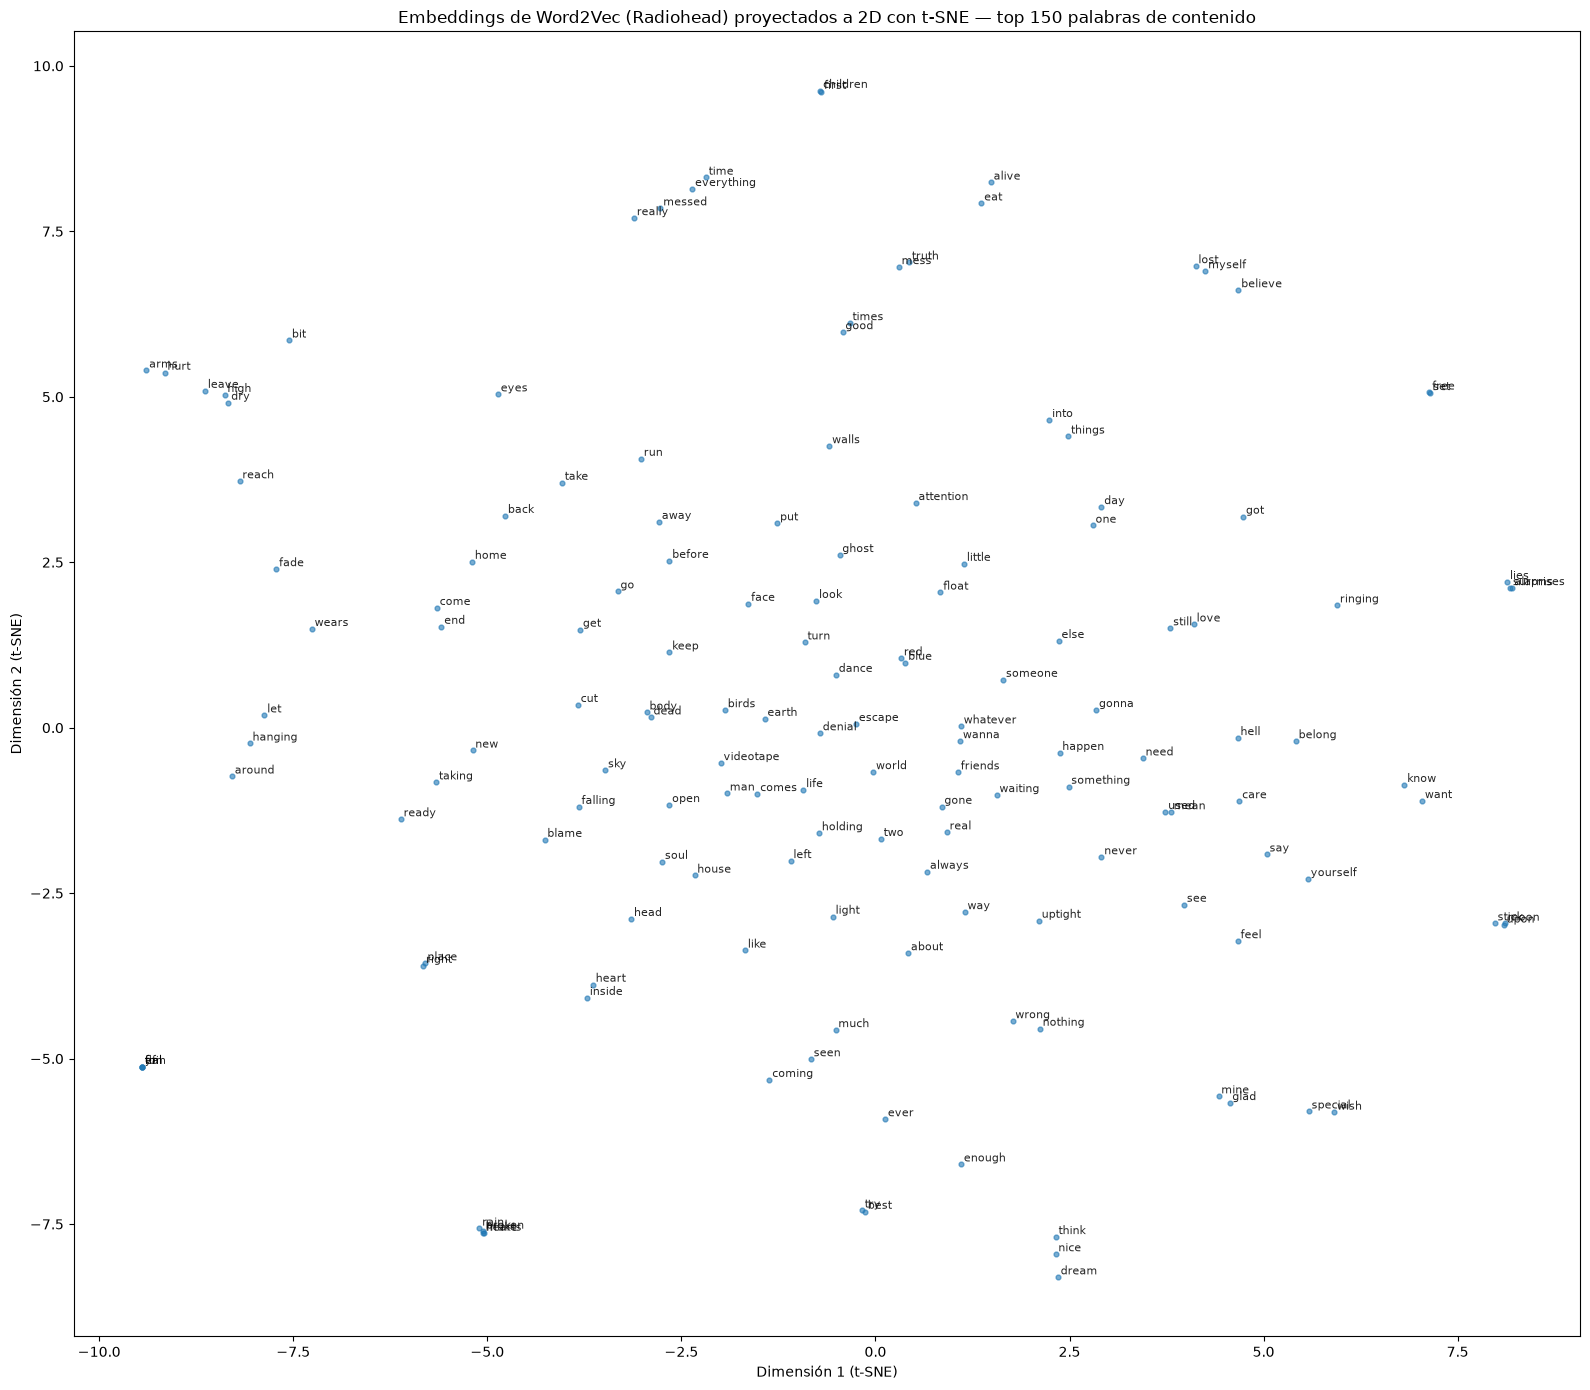

In [17]:
fig, ax = plt.subplots(figsize=(16, 14))
ax.scatter(vecs_2d[:, 0], vecs_2d[:, 1], s=12, alpha=0.6)

for word, (x, y) in zip(selected_words, vecs_2d):
    ax.annotate(word, (x, y), fontsize=8, alpha=0.85, xytext=(2, 2), textcoords="offset points")

ax.set_title(f"Embeddings de Word2Vec (Radiohead) proyectados a 2D con t-SNE — top {MAX_WORDS} palabras de contenido")
ax.set_xlabel("Dimensión 1 (t-SNE)")
ax.set_ylabel("Dimensión 2 (t-SNE)")
plt.tight_layout()
plt.show()

### 6 - Inspección de agrupamientos y conclusiones

Recorriendo el gráfico se pueden identificar algunos grupos de palabras chicos y muy compactos (varias veces casi superpuestas), que resultan bastante interpretables si se los compara con las letras originales:

- **`alarms` / `surprises`**: aparecen prácticamente pegadas. Esto se corresponde directamente con la canción *No Surprises*, cuyo estribillo repite *"no alarms and no surprises"*: al aparecer siempre en el mismo contexto inmediato (una al lado de la otra, en la misma línea, una y otra vez), Word2Vec aprende vectores casi idénticos para ambas.
- **`rain`, `broken`, `make`, `hearts`**: forman otro grupo muy compacto. Se corresponden con versos de *Fake Plastic Trees* (*"and it wears her out... it wears her out"*, *"she looks like the real thing"*) y otras canciones donde estas palabras co-ocurren repetidamente en los mismos versos con tono melancólico/de ruptura (coincide con lo que ya había aparecido al buscar `most_similar(positive=["rain"])` en la sección anterior).
- **`flah`, `fo`, `ym`, `efil`**: aparecen agrupadas y, a primera vista, no parecen palabras en inglés. Son en realidad las palabras **"half", "of", "my", "life" escritas al revés**: corresponden a *"Like Spinning Plates"*, una canción de Radiohead en la que gran parte de la letra está compuesta por audio reproducido en reversa (y transcripta fonéticamente al revés en este dataset). Como estas "palabras" solo aparecen juntas, en ese orden, dentro de esa canción, el modelo las trata como un contexto totalmente autocontenido y las agrupa entre sí, separadas del resto del vocabulario. Es un buen ejemplo de cómo Word2Vec no entiende idioma: solo aprende de co-ocurrencia estadística, así que términos sin ningún significado compartido pero que aparecen siempre en el mismo contexto (aunque sea "ruido" del dataset) terminan agrupados igual que si fueran sinónimos reales.
- **`world`, `head`, `soul`, `life`**: sin estar tan pegadas como los grupos anteriores, aparecen relativamente cercanas entre sí, en una zona del gráfico separada de las palabras más "de acción" (`run`, `hurt`, `leave`, `escape`), lo que sugiere que el modelo distingue, aunque sea de forma aproximada, entre un vocabulario más introspectivo/existencial y uno más ligado a acciones o eventos.

**Conclusión general:** con un corpus tan chico como este (una banda, ~2300 líneas), Word2Vec no llega a aprender relaciones semánticas "de diccionario" limpias como las que se obtendrían con corpus masivos (Google News, Wikipedia), pero sí captura de forma muy efectiva la **co-ocurrencia local dentro de las canciones**: frases hechas, estribillos repetidos y hasta artefactos del dataset (como el texto en reversa de *Like Spinning Plates*) generan agrupamientos muy compactos y fácilmente identificables si se conoce el corpus de origen. Esto refuerza una idea central de este tipo de embeddings: el modelo no aprende "significado" en un sentido humano, sino una geometría que refleja qué tan seguido dos palabras comparten contexto en el corpus con el que fue entrenado y por eso los embeddings de una misma palabra pueden ser completamente distintos según el corpus (no es lo mismo entrenar con letras de Radiohead que con letras de Dr. Seuss o con noticias), algo que además tiene sentido con el objetivo del desafío: generar vectores que reflejen específicamente cómo una banda particular usa las palabras en sus canciones.